# Phase 1: Data Preparation for EDSR
### This notebook processes the original SAR .tiff files to create HR and LR patch pairs for

### 1. The Cropping Script

In [4]:
!pip install tifffile --break-system-packages --quiet

In [3]:
import os
import glob
import numpy as np
import tifffile
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

# ── Settings ─────────────────────────────────────────────────
TILE_SIZE  = 256
STRIDE     = 128    # 50% overlap — same as SRCNN notebook
MIN_STD    = 5.0    # skip flat/empty tiles
SCALE      = 2      # 2x upscaling to match SRCNN
HR_FOLDER  = "EDSR_Dataset_v2/HR"
LR_FOLDER  = "EDSR_Dataset_v2/LR/X2"  # EDSR expects X2 folder for scale 2

os.makedirs(HR_FOLDER, exist_ok=True)
os.makedirs(LR_FOLDER, exist_ok=True)

# ── dB Normalization (same as before) ────────────────────────
def normalize_sar_to_uint8(band_data):
    band_data = np.clip(band_data.astype(np.float32), 1, None)
    db = 20 * np.log10(band_data)
    db_min, db_max = 28.0, 50.0
    db = np.clip(db, db_min, db_max)
    normalized = (db - db_min) / (db_max - db_min) * 255.0
    return normalized.astype(np.uint8)

# ── Process each TIFF ────────────────────────────────────────
tiff_paths = ["img1.tiff", "img2.tiff"]
total_saved = 0
total_skipped = 0

for tiff_path in tiff_paths:
    prefix = os.path.splitext(os.path.basename(tiff_path))[0]
    print(f"\nProcessing: {tiff_path}")

    raw = tifffile.imread(tiff_path)
    if raw.ndim == 3:
        raw = raw[0]

    img_uint8 = normalize_sar_to_uint8(raw)
    img = Image.fromarray(img_uint8, mode='L')
    W, H = img.size
    print(f"  Size: {W} x {H}")

    saved = 0
    skipped = 0

    for y in range(0, H - TILE_SIZE + 1, STRIDE):
        for x in range(0, W - TILE_SIZE + 1, STRIDE):
            box = (x, y, x + TILE_SIZE, y + TILE_SIZE)
            hr_patch = img.crop(box)
            arr = np.array(hr_patch)

            # Skip flat/empty patches
            if arr.std() < MIN_STD:
                skipped += 1
                continue

            # Skip patches with >10% black border pixels
            if np.mean(arr == 0) > 0.10:
                skipped += 1
                continue

            patch_name = f"{prefix}_{saved:05d}.png"

            # Save HR patch
            hr_patch.save(os.path.join(HR_FOLDER, patch_name))

            # Generate and save LR patch (bicubic 2x downscale)
            lr_patch = hr_patch.resize(
                (TILE_SIZE // SCALE, TILE_SIZE // SCALE),
                Image.Resampling.BICUBIC
            )
            lr_patch.save(os.path.join(LR_FOLDER, patch_name))

            saved += 1

    print(f"  Saved  : {saved} patches")
    print(f"  Skipped: {skipped} patches")
    total_saved += saved
    total_skipped += skipped

print(f"\nTotal HR patches : {total_saved}")
print(f"Total LR patches : {total_saved}")
print(f"Total skipped    : {total_skipped}")


Processing: img1.tiff
  Size: 26503 x 16669
  Saved  : 24731 patches
  Skipped: 1843 patches

Processing: img2.tiff
  Size: 26503 x 16669
  Saved  : 25155 patches
  Skipped: 1419 patches

Total HR patches : 49886
Total LR patches : 49886
Total skipped    : 3262


### Do sanity check of those images generated

HR patches : 49886
LR patches : 49886

Sample : img1_07476.png
  HR size : (256, 256) | mode: L
  LR size : (128, 128) | mode: L
  HR pixel range: 0 - 253


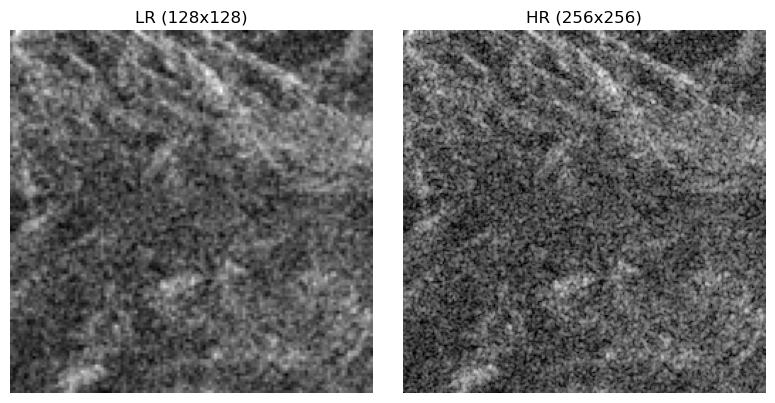

In [5]:
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

hr_folder = "EDSR_Dataset_v2/HR"
lr_folder = "EDSR_Dataset_v2/LR/X2"

hr_patches = sorted(glob.glob(os.path.join(hr_folder, "*.png")))
lr_patches = sorted(glob.glob(os.path.join(lr_folder, "*.png")))

print(f"HR patches : {len(hr_patches)}")
print(f"LR patches : {len(lr_patches)}")

sample_hr_path = random.choice(hr_patches)
filename = os.path.basename(sample_hr_path)
sample_lr_path = os.path.join(lr_folder, filename)

img_hr = Image.open(sample_hr_path)
img_lr = Image.open(sample_lr_path)

print(f"\nSample : {filename}")
print(f"  HR size : {img_hr.size} | mode: {img_hr.mode}")
print(f"  LR size : {img_lr.size} | mode: {img_lr.mode}")
print(f"  HR pixel range: {np.array(img_hr).min()} - {np.array(img_hr).max()}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_lr, cmap='gray')
axes[0].set_title("LR (128x128)")
axes[0].axis("off")
axes[1].imshow(img_hr, cmap='gray')
axes[1].set_title("HR (256x256)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# Phase 2: Generating Test Patches
### The test set is created from a separate SAR .tiff file that was not used in training. The same patch extraction and quality filtering logic is applied, but with a non-overlapping stride to ensure no data leakage between test patches.

### generate test images for evaluation

Test Image Generator
Converts a single SAR .tiff into HR and LR test patches using the same normalisation and patch logic as the training pipeline. Patches are non-overlapping (stride = tile size) so there is no data leakage between test patches.

In [1]:
import os
import glob
import numpy as np
import tifffile
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

# ── Settings (must match training pipeline) ──────────────────
TILE_SIZE   = 256
SCALE       = 2
MIN_STD     = 5.0       # same quality filter as training
DB_MIN      = 28.0
DB_MAX      = 50.0

HR_TEST_DIR = "EDSR_TestSet/HR"
LR_TEST_DIR = "EDSR_TestSet/LR/X2"

os.makedirs(HR_TEST_DIR, exist_ok=True)
os.makedirs(LR_TEST_DIR, exist_ok=True)

# ── dB normalisation (identical to training) ─────────────────
def normalize_sar_to_uint8(band_data):
    band_data = np.clip(band_data.astype(np.float32), 1, None)
    db = 20 * np.log10(band_data)
    db = np.clip(db, DB_MIN, DB_MAX)
    return ((db - DB_MIN) / (DB_MAX - DB_MIN) * 255.0).astype(np.uint8)

# ── Point this at your test TIFF ─────────────────────────────
tiff_files = glob.glob("*img3_test_set.tiff") + glob.glob("*.tif")
if not tiff_files:
    raise FileNotFoundError("No .tiff/.tif file found in the current directory.")

test_tiff_path = tiff_files[0]
print(f"Using: {test_tiff_path}")

prefix = os.path.splitext(os.path.basename(test_tiff_path))[0]

raw = tifffile.imread(test_tiff_path)
if raw.ndim == 3:
    raw = raw[0]   # take first band if multi-band

img = Image.fromarray(normalize_sar_to_uint8(raw), mode='L')
W, H = img.size
print(f"Image size: {W} x {H}")

saved   = 0
skipped = 0

# Non-overlapping stride keeps test patches independent
for y in range(0, H - TILE_SIZE + 1, TILE_SIZE):
    for x in range(0, W - TILE_SIZE + 1, TILE_SIZE):
        box      = (x, y, x + TILE_SIZE, y + TILE_SIZE)
        hr_patch = img.crop(box)
        arr      = np.array(hr_patch)

        # Same quality filters as training
        if arr.std() < MIN_STD:
            skipped += 1
            continue
        if np.mean(arr == 0) > 0.10:
            skipped += 1
            continue

        patch_name = f"{prefix}_test_{saved:04d}.png"

        hr_patch.save(os.path.join(HR_TEST_DIR, patch_name))

        lr_patch = hr_patch.resize(
            (TILE_SIZE // SCALE, TILE_SIZE // SCALE),
            Image.Resampling.BICUBIC
        )
        lr_patch.save(os.path.join(LR_TEST_DIR, patch_name))

        saved += 1

print(f"\nSaved  : {saved} test patches  (256x256 HR, 128x128 LR)")
print(f"Skipped: {skipped} patches (flat / black border)")
print(f"HR → {HR_TEST_DIR}")
print(f"LR → {LR_TEST_DIR}")


Using: img3_test_set.tiff
Image size: 26550 x 16674

Saved  : 6336 test patches  (256x256 HR, 128x128 LR)
Skipped: 359 patches (flat / black border)
HR → EDSR_TestSet/HR
LR → EDSR_TestSet/LR/X2


### Sanity check the test patches

HR test patches : 6336
LR test patches : 6336

Sample : img3_test_set_test_5133.png
  HR : (256, 256)  LR : (128, 128)


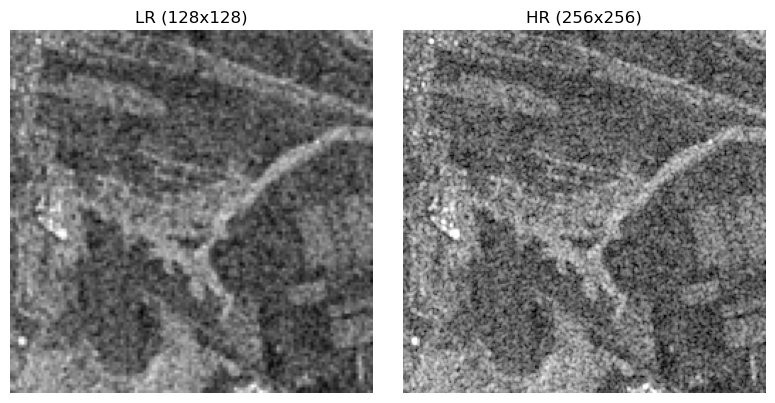

In [2]:
import random
import matplotlib.pyplot as plt

hr_patches = sorted(glob.glob(os.path.join(HR_TEST_DIR, "*.png")))
lr_patches = sorted(glob.glob(os.path.join(LR_TEST_DIR, "*.png")))

print(f"HR test patches : {len(hr_patches)}")
print(f"LR test patches : {len(lr_patches)}")

if hr_patches:
    sample_hr = random.choice(hr_patches)
    sample_lr = os.path.join(LR_TEST_DIR, os.path.basename(sample_hr))

    img_hr = Image.open(sample_hr)
    img_lr = Image.open(sample_lr)

    print(f"\nSample : {os.path.basename(sample_hr)}")
    print(f"  HR : {img_hr.size}  LR : {img_lr.size}")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_lr, cmap='gray')
    axes[0].set_title(f"LR ({img_lr.size[0]}x{img_lr.size[1]})")
    axes[0].axis("off")
    axes[1].imshow(img_hr, cmap='gray')
    axes[1].set_title(f"HR ({img_hr.size[0]}x{img_hr.size[1]})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No test patches found — check the generator cell ran successfully.")